In [ ]:
%pip install torch_geometric
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv
import torch_geometric.transforms as T

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "credit_card_transactions-ibm_v2.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ealtman2019/credit-card-transactions",
  file_path,
)

Using Colab cache for faster access to the 'credit-card-transactions' dataset.


In [ ]:
non_fraud = df[df['Is Fraud?'] == 'No']
fraud = df[df['Is Fraud?'] == 'Yes']

non_fraud_reduced = non_fraud.sample(n=len(non_fraud)-23000000, random_state=42)

df = pd.concat([fraud, non_fraud_reduced]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['Is Fraud?'].value_counts())

(1386900, 15)
Is Fraud?
No     1357143
Yes      29757
Name: count, dtype: int64


# Data cleaning

In [ ]:
# 1. Strip $ from Amount and convert to float
df['Amount'] = df['Amount'].str.replace('$', '', regex=False).astype(float)

# 2. Encode Is Fraud? to 0/1
df['Is Fraud?'] = df['Is Fraud?'].map({'Yes': 1, 'No': 0})

# 3. Extract hour from Time
df['Hour'] = df['Time'].str.split(':').str[0].astype(int)
df.drop(columns=['Time'], inplace=True)

# One-hot encode Use Chip (only 3 categories, cheap)
use_chip_dummies = pd.get_dummies(df['Use Chip'], prefix='chip').astype(np.float32)
df = pd.concat([df, use_chip_dummies], axis=1)

# MCC has too many categories for one-hot to be practical as a raw node feature.
# Frequency-encode it instead (still not ideal, but far better than raw ordinal codes).
mcc_freq = df['MCC'].value_counts(normalize=True)
df['MCC_freq'] = df['MCC'].map(mcc_freq).astype(np.float32)

In [ ]:
df.head(10)

,User,Card,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Hour,chip_Chip Transaction,chip_Online Transaction,chip_Swipe Transaction,MCC_freq
0,1560,1,2013,7,18,20.24,Online Transaction,-6458444334611773637,ONLINE,NaN,NaN,4784,NaN,0,14,0.0,1.0,0.0,0.045160
1,488,0,2003,8,23,15.43,Swipe Transaction,6621275923246397337,Los Angeles,CA,90033.0,5814,NaN,0,12,0.0,0.0,1.0,0.036468
2,1634,2,2019,8,30,2.09,Chip Transaction,-6571010470072147219,Meridian,MS,39301.0,5499,NaN,0,19,1.0,0.0,0.0,0.108432
3,1429,1,2018,11,2,52.47,Online Transaction,-2088492411650162548,ONLINE,NaN,NaN,4784,NaN,0,14,0.0,1.0,0.0,0.045160
4,1276,0,2019,9,9,37.68,Online Transaction,4241336128694185533,ONLINE,NaN,NaN,4814,NaN,0,10,0.0,1.0,0.0,0.016471
5,2,1,2009,8,27,8.23,Swipe Transaction,-4891055843221560993,West Covina,CA,91792.0,5411,NaN,0,8,0.0,0.0,1.0,0.115235
6,1458,0,2018,3,9,13.21,Chip Transaction,-4682466904892198488,Ambler,PA,19002.0,5411,NaN,0,17,1.0,0.0,0.0,0.115235
7,1687,1,2010,6,19,334.43,Online Transaction,-6796080605569913348,ONLINE,NaN,NaN,4722,NaN,0,20,0.0,1.0,0.0,0.002630
8,856,0,2012,6,11,17.60,Swipe Transaction,1351847085734910590,Sarasota,FL,34232.0,7542,NaN,0,11,0.0,0.0,1.0,0.002859
9,855,1,2018,3,17,-286.00,Chip Transaction,-3362831192073574065,Rome,Italy,NaN,7011,NaN,1,10,1.0,0.0,0.0,0.001418


In [ ]:
df["card_id"] = df["User"].astype(str) + "_" + df["Card"].astype(str)
df.drop(columns=['Merchant State', 'Card', 'User', 'Zip'])
df["Errors?"] = df["Errors?"].fillna("No error")

# Train/Test split

In [ ]:
# 1. GLOBAL ID MAPPING (Before Split)
# We map all customers and merchants to indices using the FULL dataframe.
# This ensures that "Customer A" has the same node index in both the train graph
# and the test graph, allowing us to transfer features later.
customer_ids = df["card_id"].unique()
merchant_ids = df["Merchant Name"].unique()

customer_id_map = {cid: i for i, cid in enumerate(customer_ids)}
merchant_id_map = {mid: i for i, mid in enumerate(merchant_ids)}

df["cust_node_idx"] = df["card_id"].map(customer_id_map)
df["merch_node_idx"] = df["Merchant Name"].map(merchant_id_map)

# 2. TEMPORAL SPLIT (Moved to the very top of graph building)
split_year = df['Year'].quantile(0.85)
print(f"Splitting data at year: {int(split_year)}")

train_df = df[df['Year'] < split_year].reset_index(drop=True)
test_df = df[df['Year'] >= split_year].reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Splitting data at year: 2018
Training samples: 1171626
Testing samples: 215274


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ["Amount", "Hour"]

scaler = StandardScaler()
train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
test_df[continuous_cols] = scaler.transform(test_df[continuous_cols])  # transform only, no fit — avoids leakage


# Train Graph

In [ ]:
feature_cols = [
    "Amount",
    "Hour",
    "MCC_freq",
] + list(use_chip_dummies.columns)

# --- BUILD TRAIN GRAPH ---
# Transaction features
train_transaction_x = torch.tensor(train_df[feature_cols].values.astype(np.float32), dtype=torch.float)

# Customer/Merchant features: computed using ONLY train_df!
# .reindex(customer_ids) ensures the tensor rows align with our global ID map.
# .fillna(0) handles customers/merchants that only appear in the test set (they get zero features for now).
cust_agg_train = train_df.groupby("card_id")["Amount"].agg(["mean", "count"]).reindex(customer_ids).fillna(0)
train_customer_x = torch.tensor(cust_agg_train.values.astype(np.float32), dtype=torch.float)

merch_agg_train = train_df.groupby("Merchant Name")["Amount"].agg(["mean", "count"]).reindex(merchant_ids).fillna(0)
train_merchant_x = torch.tensor(merch_agg_train.values.astype(np.float32), dtype=torch.float)

# Edges (Only from train_df)
txn_idx_train = np.arange(len(train_df))
cust_to_txn_train = torch.tensor(np.vstack([train_df["cust_node_idx"].values, txn_idx_train]), dtype=torch.long)
merch_to_txn_train = torch.tensor(np.vstack([train_df["merch_node_idx"].values, txn_idx_train]), dtype=torch.long)

# Assemble HeteroData
train_data = HeteroData()
train_data["customer"].x = train_customer_x
train_data["merchant"].x = train_merchant_x
train_data["transaction"].x = train_transaction_x
train_data["transaction"].y = torch.tensor(train_df["Is Fraud?"].values, dtype=torch.float)

train_data["customer", "made", "transaction"].edge_index = cust_to_txn_train
train_data["merchant", "involved_in", "transaction"].edge_index = merch_to_txn_train
train_data = T.ToUndirected()(train_data)

print("Train Graph:", train_data)

Train Graph: HeteroData(
  customer={ x=[5971, 2] },
  merchant={ x=[38892, 2] },
  transaction={
    x=[1171626, 6],
    y=[1171626],
  },
  (customer, made, transaction)={ edge_index=[2, 1171626] },
  (merchant, involved_in, transaction)={ edge_index=[2, 1171626] },
  (transaction, rev_made, customer)={ edge_index=[2, 1171626] },
  (transaction, rev_involved_in, merchant)={ edge_index=[2, 1171626] }
)


# Test Graph

In [ ]:
# --- BUILD TEST GRAPH ---
# Transaction features for test set
test_transaction_x = torch.tensor(test_df[feature_cols].values.astype(np.float32), dtype=torch.float)

# Inductive Features: We clone the historical train aggregates!
# This simulates looking up a customer's past behavior before predicting on a new txn.
test_customer_x = train_customer_x.clone()
test_merchant_x = train_merchant_x.clone()

# Edges (Only from test_df)
txn_idx_test = np.arange(len(test_df))
cust_to_txn_test = torch.tensor(np.vstack([test_df["cust_node_idx"].values, txn_idx_test]), dtype=torch.long)
merch_to_txn_test = torch.tensor(np.vstack([test_df["merch_node_idx"].values, txn_idx_test]), dtype=torch.long)

# Assemble Test HeteroData
test_data = HeteroData()
test_data["customer"].x = test_customer_x
test_data["merchant"].x = test_merchant_x
test_data["transaction"].x = test_transaction_x
test_data["transaction"].y = torch.tensor(test_df["Is Fraud?"].values, dtype=torch.float)

test_data["customer", "made", "transaction"].edge_index = cust_to_txn_test
test_data["merchant", "involved_in", "transaction"].edge_index = merch_to_txn_test
test_data = T.ToUndirected()(test_data)

print("Test Graph:", test_data)

Test Graph: HeteroData(
  customer={ x=[5971, 2] },
  merchant={ x=[38892, 2] },
  transaction={
    x=[215274, 6],
    y=[215274],
  },
  (customer, made, transaction)={ edge_index=[2, 215274] },
  (merchant, involved_in, transaction)={ edge_index=[2, 215274] },
  (transaction, rev_made, customer)={ edge_index=[2, 215274] },
  (transaction, rev_involved_in, merchant)={ edge_index=[2, 215274] }
)


# Model


In [ ]:
class HeteroSAGE(nn.Module):
    def __init__(self, hidden_channels, out_channels, metadata):
        super().__init__()
        edge_types = metadata[1]
        self.conv1 = HeteroConv(
            {et: SAGEConv((-1, -1), hidden_channels) for et in edge_types}, aggr="mean"
        )
        self.conv2 = HeteroConv(
            {et: SAGEConv((-1, -1), out_channels) for et in edge_types}, aggr="mean"
        )

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict

In [ ]:
class FraudHead(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.lin = nn.Linear(in_channels, 1)

    def forward(self, transaction_emb):
        return self.lin(transaction_emb).squeeze(-1)

## Training

In [ ]:
encoder = HeteroSAGE(hidden_channels=64, out_channels=32, metadata=train_data.metadata())
head = FraudHead(32)

n_pos = (train_data["transaction"].y == 1).sum().item()
n_neg = (train_data["transaction"].y == 0).sum().item()
pos_weight = torch.tensor([n_neg / n_pos])
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(head.parameters()), lr=1e-3)  # was 0.01
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

y_train = train_data["transaction"].y

print(f"Starting training with pos_weight: {pos_weight.item():.2f}")

for epoch in range(50):
    encoder.train(); head.train()
    optimizer.zero_grad()

    out_dict = encoder(train_data.x_dict, train_data.edge_index_dict)
    logits = head(out_dict["transaction"])

    loss = criterion(logits, y_train)
    loss.backward()

    # Gradient clipping — bounds how far a single update can move the weights
    torch.nn.utils.clip_grad_norm_(
        list(encoder.parameters()) + list(head.parameters()), max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)  # feed the scheduler your training loss

    if epoch % 5 == 0:
        with torch.no_grad():
            preds = (logits > 0).float()
            correct = (preds == y_train).sum().item()
            acc = correct / len(y_train)
            fraud_preds = preds.sum().item()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | Train Acc: {acc:.4f} | Fraud Preds: {int(fraud_preds)} | LR: {current_lr:.6f}")

Starting training with pos_weight: 45.53


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch 00 | Loss: 114.3503 | Train Acc: 0.4563 | Fraud Preds: 630506 | LR: 0.001000
Epoch 05 | Loss: 192.6302 | Train Acc: 0.0484 | Fraud Preds: 1136845 | LR: 0.001000
Epoch 10 | Loss: 59.9671 | Train Acc: 0.7164 | Fraud Preds: 320090 | LR: 0.001000
Epoch 15 | Loss: 24.4620 | Train Acc: 0.1981 | Fraud Preds: 946400 | LR: 0.001000
Epoch 20 | Loss: 32.4113 | Train Acc: 0.1333 | Fraud Preds: 1031969 | LR: 0.001000
Epoch 25 | Loss: 53.9060 | Train Acc: 0.7912 | Fraud Preds: 228076 | LR: 0.001000
Epoch 30 | Loss: 49.6955 | Train Acc: 0.2423 | Fraud Preds: 902370 | LR: 0.001000
Epoch 35 | Loss: 27.1119 | Train Acc: 0.6461 | Fraud Preds: 411505 | LR: 0.001000
Epoch 40 | Loss: 37.0406 | Train Acc: 0.9462 | Fraud Preds: 42434 | LR: 0.001000
Epoch 45 | Loss: 38.9814 | Train Acc: 0.3782 | Fraud Preds: 729310 | LR: 0.000500


# Merge Embeddings

In [ ]:
encoder.eval()
with torch.no_grad():
    # 1. Get embeddings for training data
    train_out_dict = encoder(train_data.x_dict, train_data.edge_index_dict)
    train_embeddings = train_out_dict["transaction"].numpy()

    # 2. Get embeddings for test data (INDUCTIVE INFERENCE)
    test_out_dict = encoder(test_data.x_dict, test_data.edge_index_dict)
    test_embeddings = test_out_dict["transaction"].numpy()

# 3. Build DataFrames for XGBoost
train_emb_df = pd.DataFrame(train_embeddings, columns=[f"gnn_emb_{i}" for i in range(train_embeddings.shape[1])])
test_emb_df = pd.DataFrame(test_embeddings, columns=[f"gnn_emb_{i}" for i in range(test_embeddings.shape[1])])

# 4. Merge with original tabular data
X_train = pd.concat([train_df.reset_index(drop=True), train_emb_df], axis=1)
X_test = pd.concat([test_df.reset_index(drop=True), test_emb_df], axis=1)

# Define targets
y_train = X_train['Is Fraud?']
y_test = X_test['Is Fraud?']
X_train = X_train.drop(columns=['Is Fraud?'])
X_test = X_test.drop(columns=['Is Fraud?'])

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1171626, 53) | Test: (215274, 53)


# Train XGBoost

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

# Drop non-numeric columns that XGBoost cannot handle
# (Fixed: you had a missing assignment operator here in the original code)
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
X_train_numeric = X_train.drop(columns=non_numeric_cols)
X_test_numeric = X_test.drop(columns  =non_numeric_cols)

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    verbosity=2,
    random_state=42
)

model.fit(
    X_train_numeric,
    y_train,
    eval_set=[(X_train_numeric, y_train), (X_test_numeric, y_test)],
    verbose=True
)

scale_pos_weight: 45.53187179792685
[06:53:26] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (1171626, 48, 56086793).
[06:53:28] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (215274, 48, 10300852).
[0]	validation_0-aucpr:0.35126	validation_1-aucpr:0.15503
[1]	validation_0-aucpr:0.35515	validation_1-aucpr:0.36492
[2]	validation_0-aucpr:0.42313	validation_1-aucpr:0.50327
[3]	validation_0-aucpr:0.42816	validation_1-aucpr:0.62024
[4]	validation_0-aucpr:0.52131	validation_1-aucpr:0.66097
[5]	validation_0-aucpr:0.61843	validation_1-aucpr:0.68918
[6]	validation_0-aucpr:0.62780	validation_1-aucpr:0.69717
[7]	validation_0-aucpr:0.63278	validation_1-aucpr:0.63958
[8]	validation_0-aucpr:0.63078	validation_1-aucpr:0.64647
[9]	validation_0-aucpr:0.64053	validation_1-aucpr:0.67070
[10]	validation_0-aucpr:0.64076	validation_1-aucpr:0.69501
[11]	validation_0-aucpr:0.63991	validati

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(model.n_features_in_)

48


# Evaluate

In [ ]:
y_pred = model.predict(X_test_numeric)
y_proba = model.predict_proba(X_test_numeric)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))


--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9813    0.9995    0.9903    210696
           1     0.8482    0.1245    0.2171      4578

    accuracy                         0.9809    215274
   macro avg     0.9148    0.5620    0.6037    215274
weighted avg     0.9785    0.9809    0.9739    215274

F1: 0.21714285714285714
ROC-AUC: 0.9833115881196959
PR-AUC: 0.8246843377534271


Hardcoded pos_weight: 45.53
Actual training ratio: 45.53
Mismatch: 1.00x wrong


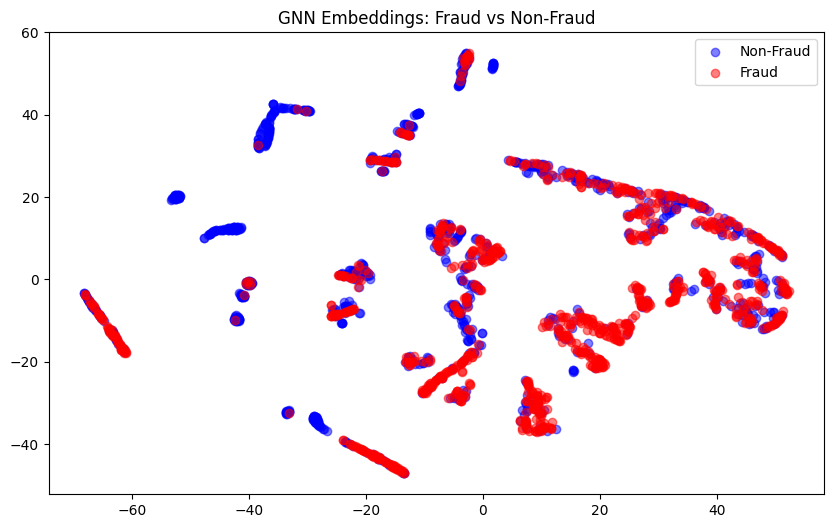

In [ ]:
# 1. Check actual training class ratio
n_pos_train = (train_data["transaction"].y == 1).sum().item()
n_neg_train = (train_data["transaction"].y == 0).sum().item()
actual_ratio = n_neg_train / n_pos_train

print(f"Hardcoded pos_weight: {pos_weight.item():.2f}")
print(f"Actual training ratio: {actual_ratio:.2f}")
print(f"Mismatch: {actual_ratio / pos_weight.item():.2f}x wrong")

# 2. Visualize embedding separation
import numpy as np
from sklearn.manifold import TSNE

# Get embeddings
encoder.eval()
with torch.no_grad():
    train_out = encoder(train_data.x_dict, train_data.edge_index_dict)
    fraud_emb = train_out["transaction"][train_data["transaction"].y == 1].numpy()
    nonfraud_emb = train_out["transaction"][train_data["transaction"].y == 0].numpy()

# t-SNE visualization
combined = np.vstack([fraud_emb[:1000], nonfraud_emb[:1000]])
labels = np.array([1]*1000 + [0]*1000)
tsne = TSNE(n_components=2, random_state=42)
embedded = tsne.fit_transform(combined)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(embedded[labels==0, 0], embedded[labels==0, 1], c='blue', alpha=0.5, label='Non-Fraud')
plt.scatter(embedded[labels==1, 0], embedded[labels==1, 1], c='red', alpha=0.5, label='Fraud')
plt.title("GNN Embeddings: Fraud vs Non-Fraud")
plt.legend()
plt.show()